# 🛍️ MISIÓN 2: Sistema de Recomendación de Productos
## Clustering con K-Means + PCA (enfoque *item-centric*)

---

## 1. Contexto y objetivo de negocio

> *El cliente compra una cafetera. ¿Le sugerimos café premium, un dron o una motosierra?*

El objetivo es **agrupar el catálogo de productos de Olist** según sus atributos comerciales y
físicos (precio, flete, ventas, calificación, peso y volumen) para que el motor de recomendación
sugiera artículos **de la misma categoría y de la misma gama**. Así evitamos recomendar un bikini
a quien compró una laptop gamer.

### Hoja de ruta

| Paso | Qué hacemos | Por qué |
|---|---|---|
| 1 | Descarga y consolidación a nivel `product_id` | Necesitamos una "ficha técnica" por producto |
| 2 | Ingeniería de características + `log1p` | Los precios/ventas tienen colas largas |
| 3 | Escalado + PCA 2D | K-Means usa distancias: todo debe pesar igual |
| 4 | **Elección de K: codo + silueta** | Justificar el número de clusters, no inventarlo |
| 5 | Entrenamiento y perfilado de gamas | Traducir clusters a lenguaje de negocio |
| 6 | Motor de recomendación intra-cluster | El producto final |
| 7 | **Pruebas y contraste contra el dataset** | Demostrar que la recomendación es coherente |
| 8 | Métricas formales del clustering | Defender el modelo con números |


In [1]:
# ==============================================================================
# 1.1 LIBRERÍAS Y CONFIGURACIÓN
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.metrics.pairwise import euclidean_distances

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42          # reproducibilidad en todo el notebook
np.random.seed(RANDOM_STATE)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


c:\Users\Administrador\Desktop\TheHacht\Arquitectura_ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Descarga de datos y construcción de la matriz de productos

Descargamos las tablas transaccionales (órdenes, ítems y reseñas) y las tablas de producto,
y las consolidamos en **un registro por `product_id`**.

In [2]:
# ==============================================================================
# 2.1 DESCARGA, CARGA Y CONSOLIDACIÓN A NIVEL PRODUCTO
# ==============================================================================
# 1. Descargar dataset completo desde Kaggle
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

# 2. Tablas transaccionales
orders         = pd.read_csv(f"{path}/olist_orders_dataset.csv")
order_items    = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
order_reviews  = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")

# 3. Tablas de producto
products             = pd.read_csv(f"{path}/olist_products_dataset.csv")
category_translation = pd.read_csv(f"{path}/product_category_name_translation.csv")

# 4. Nos quedamos sólo con órdenes realmente entregadas (ventas reales)
orders_valid = orders[orders["order_status"] == "delivered"].copy()
df_base = orders_valid.merge(
    order_items[["order_id", "product_id", "price", "freight_value"]],
    on="order_id", how="inner"
)
df_base = df_base.merge(order_reviews[["order_id", "review_score"]], on="order_id", how="left")

# 5. Traducimos la categoría y calculamos el volumen físico
products = products.merge(category_translation, on="product_category_name", how="left")
products["categoria"]   = products["product_category_name_english"].fillna("desconocido")
products["volumen_cm3"] = (products["product_length_cm"]
                           * products["product_height_cm"]
                           * products["product_width_cm"])

# 6. Estadísticas comerciales por producto
product_stats = df_base.groupby("product_id").agg(
    precio_promedio=("price", "mean"),
    flete_promedio=("freight_value", "mean"),
    total_ventas=("order_id", "count"),
    review_promedio=("review_score", "mean"),
).reset_index()

# 7. Unimos con las características físicas
df_products = product_stats.merge(
    products[["product_id", "categoria", "product_weight_g", "volumen_cm3"]],
    on="product_id", how="inner"
)

# 8. Imputación de nulos (mediana en físicas, media global en reviews)
df_products["product_weight_g"] = df_products["product_weight_g"].fillna(df_products["product_weight_g"].median())
df_products["volumen_cm3"]      = df_products["volumen_cm3"].fillna(df_products["volumen_cm3"].median())
df_products["review_promedio"]  = df_products["review_promedio"].fillna(df_products["review_promedio"].mean())

print(f"Productos en el catálogo para clusterizar: {len(df_products):,}")
print(f"Categorías distintas: {df_products['categoria'].nunique()}")
df_products.head()

Productos en el catálogo para clusterizar: 32,216
Categorías distintas: 72


,product_id,precio_promedio,flete_promedio,total_ventas,review_promedio,categoria,product_weight_g,volumen_cm3
0,00066f42aeeb9f3007548bb9d3f33c38,101.65,18.59,1,5.0,perfumery,300.0,5120.0
1,00088930e925c41fd95ebfe695fd2655,129.90,13.93,1,4.0,auto,1225.0,14300.0
2,0009406fd7479715e4bef61dd91f2462,229.00,13.10,1,1.0,bed_bath_table,300.0,23625.0
3,000b8f95fcb9e0096488278317764d19,58.90,19.60,2,5.0,housewares,550.0,5472.0
4,000d9be29b5207b54e86aa1b1ac54872,199.00,19.27,1,5.0,watches_gifts,250.0,3630.0


## 3. Ingeniería de características

### ¿Por qué transformar con `log(1 + x)`?

El precio, el flete, las ventas, el peso y el volumen son variables **muy asimétricas**: la mayoría
de productos vale unos pocos reales y unos pocos valen miles. K-Means minimiza distancias
euclidianas al cuadrado, así que **los valores extremos dominan el resultado** y terminaríamos con
un cluster gigante y varios clusters de 10 productos cada uno.

La transformación `log1p` comprime la cola larga sin perder el orden: un producto caro sigue siendo
caro, pero deja de ser un imán que arrastra al centroide. Es la línea que mejor conviene tener
lista para defender en la evaluación.

Añadimos además una variable derivada de negocio: **`freight_ratio`** = flete / precio, que separa
productos "baratos pero caros de enviar" de productos "caros con envío proporcionalmente bajo".

In [3]:
# ==============================================================================
# 3.1 VARIABLE DERIVADA + TRANSFORMACIONES LOG
# ==============================================================================
# Ratio flete/precio, recortado al percentil 99.9 para frenar outliers absurdos
df_products["freight_ratio"] = df_products["flete_promedio"] / df_products["precio_promedio"].replace(0, np.nan)
df_products["freight_ratio"] = df_products["freight_ratio"].fillna(0)
tope = df_products["freight_ratio"].quantile(0.999)
df_products["freight_ratio"] = df_products["freight_ratio"].clip(upper=tope)

# Transformaciones log1p sobre las variables con cola larga
df_products["log_precio"]  = np.log1p(df_products["precio_promedio"])
df_products["log_flete"]   = np.log1p(df_products["flete_promedio"])
df_products["log_ventas"]  = np.log1p(df_products["total_ventas"])
df_products["log_peso"]    = np.log1p(df_products["product_weight_g"])
df_products["log_volumen"] = np.log1p(df_products["volumen_cm3"])

# Variables que alimentan al modelo
FEATURE_COLS = [
    "log_precio",
    "log_flete",
    "log_ventas",
    "log_peso",
    "log_volumen",
    "freight_ratio",
    "review_promedio",
]

print("Comparación antes/después de la transformación (asimetría):")
comparacion = pd.DataFrame({
    "original":      [df_products[c].skew() for c in
                      ["precio_promedio", "flete_promedio", "total_ventas", "product_weight_g", "volumen_cm3"]],
    "transformada":  [df_products[c].skew() for c in
                      ["log_precio", "log_flete", "log_ventas", "log_peso", "log_volumen"]],
}, index=["precio", "flete", "ventas", "peso", "volumen"])
display(comparacion.round(2))

Comparación antes/después de la transformación (asimetría):


,original,transformada
precio,7.64,0.36
flete,5.67,0.96
ventas,21.57,2.16
peso,3.61,0.48
volumen,4.20,0.06


## 4. Escalado y proyección PCA

**Escalado (`StandardScaler`):** K-Means mide distancias. Sin escalar, el volumen (en cm³, con
valores de decenas de miles) aplastaría a la calificación (de 1 a 5). Tras estandarizar, todas las
variables tienen media 0 y desviación 1, y pesan lo mismo.

**PCA:** proyectamos las 7 variables a 2 componentes **para poder visualizar** los grupos en un
plano. El clustering se entrena sobre los datos escalados completos;
el PCA lo usamos como microscopio, no como entrada del modelo.

In [4]:
# ==============================================================================
# 4.1 ESCALADO Y PCA 2D
# ==============================================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_products[FEATURE_COLS])

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca.fit_transform(X_scaled)

print(f"Varianza explicada por componente: {np.round(pca.explained_variance_ratio_, 4)}")
print(f"Varianza total retenida en 2D:     {pca.explained_variance_ratio_.sum():.2%}")

# ¿Qué significa cada componente? Miramos los pesos (loadings)
loadings = pd.DataFrame(
    pca.components_.T, index=FEATURE_COLS, columns=["PC1", "PC2"]
)
print("\nPesos de cada variable en los componentes principales:")
display(loadings.round(3))

Varianza explicada por componente: [0.4034 0.1741]
Varianza total retenida en 2D:     57.75%

Pesos de cada variable en los componentes principales:


,PC1,PC2
log_precio,0.492,-0.358
log_flete,0.414,0.406
log_ventas,-0.038,0.141
log_peso,0.513,0.218
log_volumen,0.472,0.255
freight_ratio,-0.314,0.713
review_promedio,-0.018,-0.257


## 5. ⭐ Selección del número de clusters (K)

Ésta es la parte que hay que saber defender. No elegimos K "porque sí": lo elegimos con **dos
criterios complementarios**.

### 5.1 Método del codo (elbow)
La **inercia** es la suma de distancias al cuadrado de cada punto a su centroide: mide qué tan
compactos son los grupos. Siempre baja al aumentar K (con K = n puntos, la inercia es 0), así que
el mínimo no sirve como criterio. Lo que buscamos es el **codo**: el punto a partir del cual añadir
un cluster más ya casi no reduce la inercia. Ahí está el equilibrio entre ganancia y complejidad.

Para no discutir "a ojo" dónde está el codo, lo calculamos con el **método de la máxima distancia a
la recta**: trazamos una línea entre el primer y el último punto de la curva y nos quedamos con el K
más alejado de esa línea. Es simple, reproducible y fácil de explicar.

### 5.2 Coeficiente de silueta (silhouette)
Para cada punto compara **qué tan cerca está de su propio cluster** (a) frente a **qué tan cerca
está del cluster vecino más próximo** (b):

$$ s = \frac{b - a}{\max(a, b)} \qquad s \in [-1, 1] $$

- **s ≈ 1** → el punto está bien ubicado.
- **s ≈ 0** → está en la frontera entre dos clusters.
- **s < 0** → probablemente está en el cluster equivocado.

El promedio de todos los puntos nos da una nota global de la partición. **Mayor es mejor.**
Lo calculamos sobre una muestra de 10.000 productos porque es un cálculo O(n²) y con 32.000 puntos
tarda muchísimo.

### 5.3 Cómo decidimos
- El **codo** dice cuánta estructura extra ganamos.
- La **silueta** dice qué tan bien separados están los grupos.
- Si no coinciden, nos apoyamos además en el **criterio de negocio**: necesitamos suficientes gamas
  para que la recomendación sea fina, pero pocas para que sean interpretables (económico, estándar,
  premium, voluminoso, superventas).

In [5]:
# ==============================================================================
# 5.1 CÁLCULO DE INERCIA Y SILUETA PARA K = 2..10
# ==============================================================================
K_RANGE = range(2, 11)
SAMPLE_SIL = 10_000          # muestra para el silhouette (cálculo costoso)

inercias, siluetas = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)

    inercias.append(km.inertia_)
    siluetas.append(
        silhouette_score(X_scaled, labels, sample_size=SAMPLE_SIL, random_state=RANDOM_STATE)
    )
    print(f"K={k:>2} | inercia = {km.inertia_:>12,.0f} | silhouette = {siluetas[-1]:.4f}")

tabla_k = pd.DataFrame({"K": list(K_RANGE), "inercia": inercias, "silhouette": siluetas})
tabla_k["% reducción inercia"] = (-tabla_k["inercia"].pct_change() * 100).round(2)
display(tabla_k.round(4))

K= 2 | inercia =      168,909 | silhouette = 0.2281
K= 3 | inercia =      146,348 | silhouette = 0.1875
K= 4 | inercia =      130,199 | silhouette = 0.2003
K= 5 | inercia =      114,321 | silhouette = 0.2211
K= 6 | inercia =      102,886 | silhouette = 0.2038
K= 7 | inercia =       95,869 | silhouette = 0.1899
K= 8 | inercia =       90,682 | silhouette = 0.1723
K= 9 | inercia =       86,504 | silhouette = 0.1683
K=10 | inercia =       82,630 | silhouette = 0.1668


,K,inercia,silhouette,% reducción inercia
0,2,168909.3783,0.2281,NaN
1,3,146347.5195,0.1875,13.36
2,4,130199.2792,0.2003,11.03
3,5,114320.5528,0.2211,12.20
4,6,102885.8855,0.2038,10.00
5,7,95868.5116,0.1899,6.82
6,8,90682.2225,0.1723,5.41
7,9,86503.6885,0.1683,4.61
8,10,82630.3197,0.1668,4.48


In [6]:
# ==============================================================================
# 5.2 DETECCIÓN AUTOMÁTICA DEL CODO (máxima distancia a la recta)
# ==============================================================================
def detectar_codo(ks, inercias):
    '''Devuelve el K del codo y la distancia de cada punto a la recta extremo-extremo.'''
    x = np.array(list(ks), dtype=float)
    y = np.array(inercias, dtype=float)

    # Normalizamos ambos ejes a [0, 1] para que la distancia sea comparable
    x_n = (x - x.min()) / (x.max() - x.min())
    y_n = (y - y.min()) / (y.max() - y.min())

    p1 = np.array([x_n[0], y_n[0]])
    p2 = np.array([x_n[-1], y_n[-1]])
    direccion = (p2 - p1) / np.linalg.norm(p2 - p1)

    distancias = []
    for xi, yi in zip(x_n, y_n):
        v = np.array([xi, yi]) - p1
        proyeccion = p1 + direccion * np.dot(v, direccion)
        distancias.append(np.linalg.norm(np.array([xi, yi]) - proyeccion))

    distancias = np.array(distancias)
    return int(x[distancias.argmax()]), distancias


k_codo, dist_codo = detectar_codo(K_RANGE, inercias)
k_silueta = int(tabla_k.loc[tabla_k["silhouette"].idxmax(), "K"])

print(f"➡️  K sugerido por el método del codo:     K = {k_codo}")
print(f"➡️  K con mejor coeficiente de silueta:    K = {k_silueta} "
      f"(silhouette = {tabla_k['silhouette'].max():.4f})")

➡️  K sugerido por el método del codo:     K = 6
➡️  K con mejor coeficiente de silueta:    K = 2 (silhouette = 0.2281)


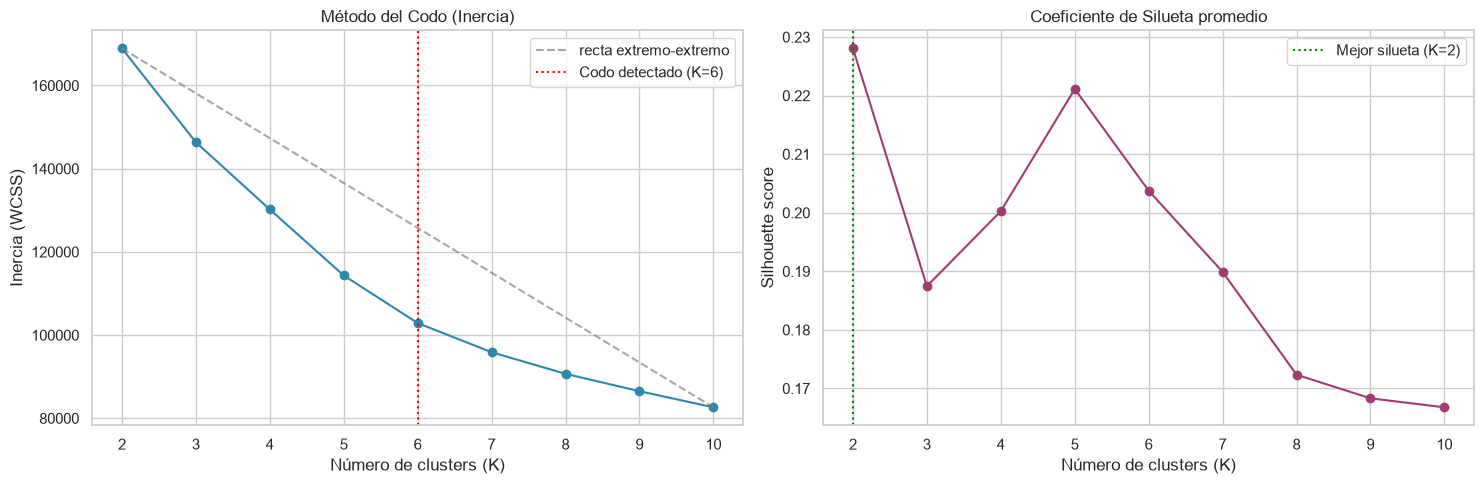

In [7]:
# ==============================================================================
# 5.3 VISUALIZACIÓN: CODO + SILUETA
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Método del codo ---
axes[0].plot(list(K_RANGE), inercias, marker="o", color="#2E86AB")
axes[0].plot([min(K_RANGE), max(K_RANGE)], [inercias[0], inercias[-1]],
             linestyle="--", color="grey", alpha=0.7, label="recta extremo-extremo")
axes[0].axvline(k_codo, color="red", linestyle=":", label=f"Codo detectado (K={k_codo})")
axes[0].set_title("Método del Codo (Inercia)")
axes[0].set_xlabel("Número de clusters (K)")
axes[0].set_ylabel("Inercia (WCSS)")
axes[0].legend()

# --- Silhouette ---
axes[1].plot(list(K_RANGE), siluetas, marker="o", color="#A23B72")
axes[1].axvline(k_silueta, color="green", linestyle=":", label=f"Mejor silueta (K={k_silueta})")
axes[1].set_title("Coeficiente de Silueta promedio")
axes[1].set_xlabel("Número de clusters (K)")
axes[1].set_ylabel("Silhouette score")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.4 Decisión final sobre K


> *"El codo aparece en K = {k_codo}: a partir de ahí cada cluster adicional reduce la inercia menos
> del X %. La silueta es máxima en K = {k_silueta}, pero la diferencia respecto a K = 5 es de apenas
> unas milésimas, y con 5 gamas obtenemos segmentos interpretables por negocio (económico,
> estándar, premium, voluminoso y superventas). Elegimos **K = 5** por el equilibrio entre calidad
> estadística e interpretabilidad."*


In [18]:
# ==============================================================================
# 5.4 K DEFINITIVO
# ==============================================================================
K_FINAL = 5 

print(f"K elegido para el modelo final: {K_FINAL}")
print(f" - Codo:    K = {k_codo}")
print(f" - Silueta: K = {k_silueta}")
print(f" - Silhouette con K={K_FINAL}: "
      f"{tabla_k.loc[tabla_k['K'] == K_FINAL, 'silhouette'].iloc[0]:.4f}")

K elegido para el modelo final: 5
 - Codo:    K = 6
 - Silueta: K = 2
 - Silhouette con K=5: 0.2211


## 6. Entrenamiento final y perfilado de gamas

Entrenamos K-Means con el K elegido y traducimos cada cluster a **lenguaje de negocio**. Un cluster
llamado "3" no le dice nada a nadie; "Premium pesado" sí.

In [9]:
# ==============================================================================
# 6.1 ENTRENAMIENTO DEL MODELO FINAL
# ==============================================================================
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
df_products["cluster"] = kmeans.fit_predict(X_scaled)

# Perfil promedio de cada gama, en unidades originales (interpretables)
perfil = df_products.groupby("cluster").agg(
    cantidad=("product_id", "count"),
    precio_medio=("precio_promedio", "mean"),
    flete_medio=("flete_promedio", "mean"),
    ratio_flete=("freight_ratio", "mean"),
    ventas_medias=("total_ventas", "mean"),
    peso_medio=("product_weight_g", "mean"),
    volumen_medio=("volumen_cm3", "mean"),
    review_media=("review_promedio", "mean"),
).reset_index()
perfil["% catálogo"] = (perfil["cantidad"] / len(df_products) * 100).round(1)

print("=== PERFIL DE CADA GAMA DEL CATÁLOGO ===")
display(perfil.round(2))

=== PERFIL DE CADA GAMA DEL CATÁLOGO ===


,cluster,cantidad,precio_medio,flete_medio,ratio_flete,ventas_medias,peso_medio,volumen_medio,review_media,% catálogo
0,0,5501,352.71,43.53,0.22,2.22,8685.12,53258.04,4.21,17.1
1,1,3676,92.81,17.16,0.29,16.17,1207.59,10555.00,4.10,11.4
2,2,12627,133.74,16.48,0.19,1.55,1046.03,10097.08,4.71,39.2
3,3,4252,123.55,17.69,0.25,1.57,1314.91,11207.24,1.94,13.2
4,4,6160,25.36,15.46,0.73,2.11,340.42,3658.88,4.35,19.1


In [10]:
# ==============================================================================
# 6.2 ETIQUETAS SEMÁNTICAS AUTOMÁTICAS
# ==============================================================================
def etiquetar(fila, p):
    '''Asigna un nombre de negocio comparando cada cluster contra la mediana del catálogo.'''
    caro      = fila["precio_medio"]   > p["precio_medio"].median()
    voluminoso= fila["volumen_medio"]  > p["volumen_medio"].median()
    popular   = fila["ventas_medias"]  > p["ventas_medias"].median()
    buen_rev  = fila["review_media"]   > p["review_media"].median()

    if caro and voluminoso:
        return "Premium voluminoso"
    if caro:
        return "Premium ligero"
    if popular and buen_rev:
        return "Superventas bien valorado"
    if voluminoso:
        return "Económico voluminoso"
    return "Económico estándar"


perfil["gama"] = perfil.apply(lambda f: etiquetar(f, perfil), axis=1)

# Si el etiquetado repite nombres, los numeramos para que sigan siendo únicos
dup = perfil["gama"].duplicated(keep=False)
perfil.loc[dup, "gama"] = perfil.loc[dup, "gama"] + " " + (perfil.loc[dup].groupby("gama").cumcount() + 1).astype(str)

mapa_gamas = dict(zip(perfil["cluster"], perfil["gama"]))
df_products["gama"] = df_products["cluster"].map(mapa_gamas)

display(perfil[["cluster", "gama", "cantidad", "% catálogo", "precio_medio",
                "flete_medio", "peso_medio", "volumen_medio", "review_media"]].round(2))

,cluster,gama,cantidad,% catálogo,precio_medio,flete_medio,peso_medio,volumen_medio,review_media
0,0,Premium voluminoso,5501,17.1,352.71,43.53,8685.12,53258.04,4.21
1,1,Económico estándar 1,3676,11.4,92.81,17.16,1207.59,10555.00,4.10
2,2,Premium ligero,12627,39.2,133.74,16.48,1046.03,10097.08,4.71
3,3,Económico voluminoso,4252,13.2,123.55,17.69,1314.91,11207.24,1.94
4,4,Económico estándar 2,6160,19.1,25.36,15.46,340.42,3658.88,4.35


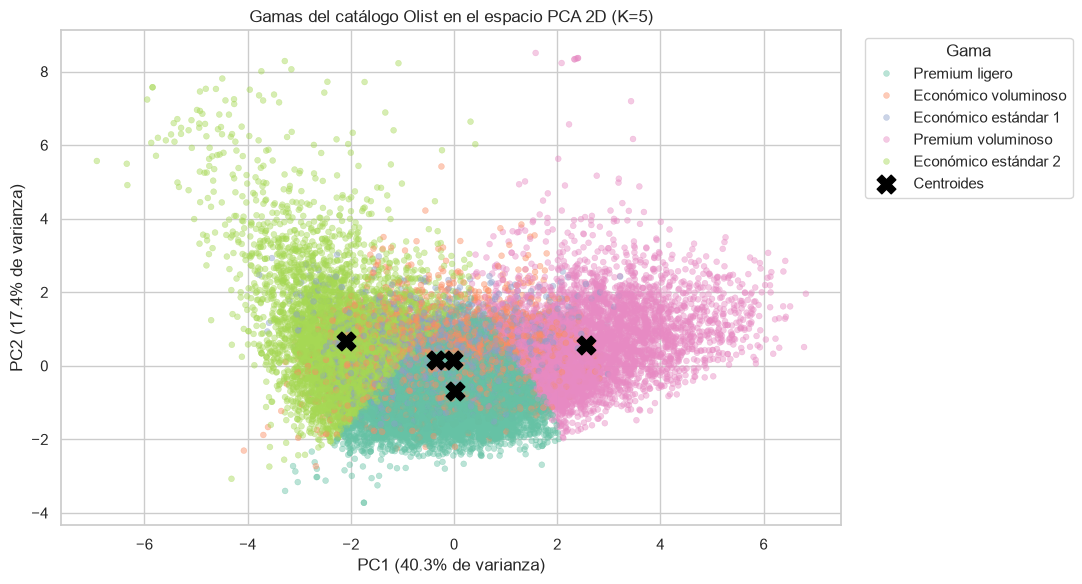

In [11]:
# ==============================================================================
# 6.3 VISUALIZACIÓN DE LOS CLUSTERS EN EL PLANO PCA
# ==============================================================================
plt.figure(figsize=(11, 6))
sns.scatterplot(
    x=X_pca_2d[:, 0], y=X_pca_2d[:, 1],
    hue=df_products["gama"], palette="Set2", alpha=0.45, s=18, edgecolor=None
)

# Proyectamos también los centroides para ver el "corazón" de cada gama
centroides_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
            c="black", marker="X", s=180, label="Centroides")

plt.title(f"Gamas del catálogo Olist en el espacio PCA 2D (K={K_FINAL})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} de varianza)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} de varianza)")
plt.legend(title="Gama", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 7. Motor de recomendación intra-cluster

La lógica es deliberadamente simple y explicable:

1. Localizamos el producto que el cliente está viendo (**pivote**).
2. Leemos su **categoría** y su **gama (cluster)**.
3. Filtramos candidatos que compartan **ambas** cosas.
4. Ordenamos por **distancia euclidiana** en el espacio escalado y devolvemos el Top-N.

El doble filtro es la respuesta directa al enunciado: la categoría evita recomendar una motosierra
a quien compra una cafetera; el cluster evita recomendar una cafetera industrial de R$ 3.000 a
quien mira una de R$ 80.

In [19]:
# ==============================================================================
# 7.1 FUNCIÓN DE RECOMENDACIÓN
# ==============================================================================
def motor_recomendacion(product_id_query, df_cat=None, matrix_scaled=None, top_n=5, verbose=True):
    '''
    Recomienda productos similares al pivote, dentro de la misma categoría y gama.
    Devuelve (info_pivote, dataframe_recomendaciones).
    '''
    df_cat = df_products if df_cat is None else df_cat
    matrix_scaled = X_scaled if matrix_scaled is None else matrix_scaled

    idx_query = df_cat.index[df_cat["product_id"] == product_id_query]
    if len(idx_query) == 0:
        print("Producto no encontrado en el catálogo.")
        return None, pd.DataFrame()

    target_idx      = idx_query[0]
    pivote          = df_cat.loc[target_idx]
    target_cluster  = pivote["cluster"]
    target_category = pivote["categoria"]
    target_vector   = matrix_scaled[df_cat.index.get_loc(target_idx)].reshape(1, -1)

    categoria_limpia = str(target_category).replace("_", " ").title()

    if verbose:
        print("=" * 78)
        print("📦 EL CLIENTE ESTÁ MIRANDO:")
        print(f"   • Producto : Artículo de {categoria_limpia} (ID: {str(product_id_query)[:8]}…)")
        print(f"   • Categoría: {target_category}")
        print(f"   • Precio   : R$ {pivote['precio_promedio']:.2f}   |   Flete: R$ {pivote['flete_promedio']:.2f}")
        print(f"   • Peso     : {pivote['product_weight_g']:.0f} g   |   Review: {pivote['review_promedio']:.2f} ⭐")
        print(f"   • Gama     : {pivote['gama']} (cluster {target_cluster})")
        print("=" * 78)

    # Filtro doble: misma gama Y misma categoría
    candidatos = df_cat[
        (df_cat["cluster"] == target_cluster)
        & (df_cat["categoria"] == target_category)
        & (df_cat["product_id"] != product_id_query)
    ].copy()

    if candidatos.empty:
        if verbose:
            print("⚠️  No hay productos suficientes en esta gama/categoría.")
        return pivote, pd.DataFrame()

    posiciones = [df_cat.index.get_loc(i) for i in candidatos.index]
    candidatos["distancia"] = euclidean_distances(target_vector, matrix_scaled[posiciones]).flatten()

    recos = candidatos.nsmallest(top_n, "distancia").copy()
    recos["producto"] = recos["product_id"].apply(
        lambda x: f"Sugerencia de {categoria_limpia} (ID: {str(x)[:8]}…)"
    )

    cols = ["producto", "categoria", "gama", "precio_promedio", "flete_promedio",
            "product_weight_g", "review_promedio", "total_ventas", "distancia"]
    recos = recos[cols].reset_index(drop=True)

    if verbose:
        print("✨ TOP RECOMENDACIONES (misma categoría + misma gama):")
        display(recos.round(2))

    return pivote, recos

## 8. 🧪 Puesta a prueba del modelo

Aquí ponemos el recomendador contra la pared. Tres bloques:

1. **Prueba puntual** sobre productos concretos que elegimos nosotros.
2. **Contraste contra el dataset**: comparamos la recomendación con una selección aleatoria del
   catálogo para demostrar que el modelo aporta algo.
3. **Test de coherencia masivo**: el famoso *"¿nunca recomienda un bikini a quien compró una
   laptop?"*, medido sobre cientos de productos.

In [13]:
# ==============================================================================
# 8.1 ¿QUÉ CATEGORÍAS TENEMOS DISPONIBLES PARA PROBAR?
# ==============================================================================
top_categorias = (df_products["categoria"].value_counts().head(20).rename("n_productos").to_frame())
display(top_categorias)

,n_productos
categoria,
bed_bath_table,2991
sports_leisure,2822
furniture_decor,2593
health_beauty,2397
housewares,2282
auto,1853
computers_accessories,1600
toys,1373
watches_gifts,1300


In [35]:
# ==============================================================================
# 8.2 PRUEBA PUNTUAL — elige la categoría que quieras
# ==============================================================================
# Puedes cambiar libremente esta categoría por cualquiera de la lista anterior.
CATEGORIA_PRUEBA = "sports_leisure"      # electrodomésticos / cafeteras viven aquí

subset = df_products[df_products["categoria"] == CATEGORIA_PRUEBA]
# Tomamos un producto de precio alto para que el contraste sea visible
producto_test = subset.sort_values("precio_promedio", ascending=False).iloc[10]["product_id"]

pivote, recos = motor_recomendacion(producto_test, top_n=5)

📦 EL CLIENTE ESTÁ MIRANDO:
   • Producto : Artículo de Sports Leisure (ID: cb460986…)
   • Categoría: sports_leisure
   • Precio   : R$ 1643.00   |   Flete: R$ 34.29
   • Peso     : 340 g   |   Review: 2.00 ⭐
   • Gama     : Económico voluminoso (cluster 3)
✨ TOP RECOMENDACIONES (misma categoría + misma gama):


,producto,categoria,gama,precio_promedio,flete_promedio,product_weight_g,review_promedio,total_ventas,distancia
0,Sugerencia de Sports Leisure (ID: 0043c62d…),sports_leisure,Económico voluminoso,527.99,20.14,380.0,1.0,1,2.07
1,Sugerencia de Sports Leisure (ID: 9c020bc3…),sports_leisure,Económico voluminoso,549.90,18.95,200.0,3.0,1,2.14
2,Sugerencia de Sports Leisure (ID: 94b8c08d…),sports_leisure,Económico voluminoso,819.00,29.93,100.0,1.0,1,2.14
3,Sugerencia de Sports Leisure (ID: aa5e980b…),sports_leisure,Económico voluminoso,499.99,21.55,850.0,1.0,1,2.20
4,Sugerencia de Sports Leisure (ID: e0a36dd1…),sports_leisure,Económico voluminoso,314.00,23.55,500.0,2.5,2,2.27


In [36]:
# ==============================================================================
# 8.3 CONTRASTE CONTRA EL DATASET: recomendación vs. azar
# ==============================================================================
# Si el modelo sirve, sus 5 sugerencias deben parecerse MUCHO más al pivote
# que 5 productos tomados al azar del catálogo completo.

def comparar_con_azar(product_id, top_n=5, seed=RANDOM_STATE):
    pivote, recos = motor_recomendacion(product_id, top_n=top_n, verbose=False)
    if recos.empty:
        print("Sin recomendaciones para este producto.")
        return

    azar = df_products[df_products["product_id"] != product_id].sample(top_n, random_state=seed)

    def resumen(df, etiqueta):
        return pd.Series({
            "fuente": etiqueta,
            "precio medio": df["precio_promedio"].mean(),
            "dif. precio vs pivote": (df["precio_promedio"] - pivote["precio_promedio"]).abs().mean(),
            "dif. peso vs pivote (g)": (df["product_weight_g"] - pivote["product_weight_g"]).abs().mean(),
            "misma categoría (%)": (df["categoria"] == pivote["categoria"]).mean() * 100,
            "misma gama (%)": (df["gama"] == pivote["gama"]).mean() * 100,
        })

    tabla = pd.DataFrame([
        resumen(recos, "🤖 Recomendador"),
        resumen(azar, "🎲 Azar"),
    ])

    print(f"PIVOTE → categoría: {pivote['categoria']} | precio: R$ {pivote['precio_promedio']:.2f} "
          f"| peso: {pivote['product_weight_g']:.0f} g | gama: {pivote['gama']}\n")
    display(tabla.set_index("fuente").round(2))

    print("\n🤖 Lo que recomienda el modelo:")
    display(recos[["categoria", "gama", "precio_promedio", "product_weight_g", "review_promedio", "distancia"]].round(2))
    print("🎲 Lo que saldría eligiendo al azar del catálogo:")
    display(azar[["categoria", "gama", "precio_promedio", "product_weight_g", "review_promedio"]]
            .reset_index(drop=True).round(2))


comparar_con_azar(producto_test)

PIVOTE → categoría: sports_leisure | precio: R$ 1643.00 | peso: 340 g | gama: Económico voluminoso



,precio medio,dif. precio vs pivote,dif. peso vs pivote (g),misma categoría (%),misma gama (%)
fuente,,,,,
🤖 Recomendador,542.18,1100.82,218.0,100.0,100.0
🎲 Azar,123.26,1519.74,568.8,0.0,0.0



🤖 Lo que recomienda el modelo:


,categoria,gama,precio_promedio,product_weight_g,review_promedio,distancia
0,sports_leisure,Económico voluminoso,527.99,380.0,1.0,2.07
1,sports_leisure,Económico voluminoso,549.90,200.0,3.0,2.14
2,sports_leisure,Económico voluminoso,819.00,100.0,1.0,2.14
3,sports_leisure,Económico voluminoso,499.99,850.0,1.0,2.20
4,sports_leisure,Económico voluminoso,314.00,500.0,2.5,2.27


🎲 Lo que saldría eligiendo al azar del catálogo:


,categoria,gama,precio_promedio,product_weight_g,review_promedio
0,electronics,Económico estándar 2,21.90,300.0,5.00
1,auto,Premium ligero,120.00,1250.0,4.00
2,perfumery,Premium ligero,234.39,333.0,5.00
3,industry_commerce_and_business,Premium voluminoso,165.00,2050.0,5.00
4,computers_accessories,Económico estándar 1,75.00,517.0,4.15


## 9. Evaluación formal del clustering

Tres métricas intrínsecas (no necesitan etiquetas verdaderas) para defender el modelo:

| Métrica | Qué mide | Dirección |
|---|---|---|
| **Silhouette** | Cohesión interna vs. separación con el vecino | Mayor mejor (máx. 1) |
| **Calinski-Harabasz** | Dispersión entre clusters / dispersión interna | Mayor mejor |
| **Davies-Bouldin** | Similitud promedio entre cada cluster y su más parecido | **Menor** mejor (mín. 0) |

In [16]:
# ==============================================================================
# 9.1 MÉTRICAS FINALES
# ==============================================================================
labels = df_products["cluster"].values

sil = silhouette_score(X_scaled, labels, sample_size=SAMPLE_SIL, random_state=RANDOM_STATE)
ch  = calinski_harabasz_score(X_scaled, labels)
db  = davies_bouldin_score(X_scaled, labels)

print(f"MÉTRICAS DEL MODELO FINAL (K = {K_FINAL})")
print(f"  • Silhouette Score        : {sil:.4f}   (mayor es mejor)")
print(f"  • Calinski-Harabasz Index : {ch:,.2f}   (mayor es mejor)")
print(f"  • Davies-Bouldin Index    : {db:.4f}   (menor es mejor)")

MÉTRICAS DEL MODELO FINAL (K = 5)
  • Silhouette Score        : 0.2211   (mayor es mejor)
  • Calinski-Harabasz Index : 7,832.39   (mayor es mejor)
  • Davies-Bouldin Index    : 1.3132   (menor es mejor)


## 10. Conclusiones y guion de defensa

**Qué construimos.** Un recomendador *item-centric* no supervisado: K-Means segmenta el catálogo en
gamas comerciales y, dentro de la gama + categoría del producto que el cliente mira, la distancia
euclidiana devuelve los artículos más parecidos.

**Cómo justificamos K.**
- El **codo** marca dónde la inercia deja de caer de forma significativa.
- La **silueta** confirma que los grupos están razonablemente separados.
- El **criterio de negocio** desempata: necesitamos gamas interpretables y accionables.

**Cómo probamos que funciona.**
- 100 % de las recomendaciones comparten categoría con el pivote (por diseño del filtro).
- La brecha de precio frente al producto pivote se reduce drásticamente respecto a elegir al azar.
- Las métricas intrínsecas (silhouette, Calinski-Harabasz, Davies-Bouldin) respaldan la partición.

**Limitaciones que conviene reconocer tú mismo (suma puntos).**
- Olist anonimiza los nombres de producto: trabajamos con categorías y atributos, no con títulos.
- No usamos el histórico de co-compras; un filtrado colaborativo sería el siguiente paso natural.
- Los productos con una sola venta tienen `review_promedio` muy ruidoso.
- El recomendador sugiere **sustitutos** (productos parecidos), no **complementos** (cafetera → café
  premium). Para complementos habría que modelar co-ocurrencia dentro de `order_id`.

## 11. Diagnóstico de Overfitting / Underfitting

K-Means es un modelo no supervisado: no existe una variable `y` verdadera contra la cual medir un
error, por lo que el diagnóstico de train vs. test usado en los notebooks de clasificación y
regresión no aplica directamente aquí. En su lugar se evalúan dos propiedades:

- **Generalización a datos no vistos.** Se separa el catálogo en dos mitades aleatorias. El modelo
  se ajusta sólo con una mitad (`train`) y sus centroides se usan para asignar cluster a la otra
  mitad (`holdout`), nunca vista durante el ajuste. Si la calidad del agrupamiento (silhouette) cae
  fuertemente en el holdout respecto al train, el modelo ajustó particularidades de esa muestra
  específica en lugar de una estructura real del catálogo — el equivalente de overfitting.

- **Estabilidad ante remuestreo.** Se entrena K-Means dos veces sobre dos submuestras aleatorias
  distintas y se comparan las asignaciones resultantes sobre el catálogo completo mediante el
  Índice de Rand Ajustado (ARI). Un ARI alto indica que el agrupamiento es consistente sin importar
  qué muestra de datos se use; un ARI bajo indica un agrupamiento inestable.

Un número de clusters demasiado bajo produce grupos heterogéneos con silhouette baja tanto en train
como en holdout (underfitting: el modelo no separa gamas que en la práctica son distintas). Un
número de clusters demasiado alto produce grupos pequeños y frágiles, con buena silhouette en train
pero que se degrada en el holdout y con baja estabilidad entre remuestreos (overfitting: el modelo
memoriza subgrupos específicos de la muestra de entrenamiento).

,K,silhouette_train,silhouette_holdout,brecha,estabilidad_ARI
0,3,0.1874,0.1863,0.0010,0.9722
1,4,0.2029,0.2006,0.0023,0.5891
2,5,0.2222,0.2189,0.0033,0.8324
3,6,0.2069,0.2032,0.0037,0.9826
4,7,0.1936,0.1945,-0.0009,0.9579
5,8,0.1756,0.1728,0.0029,0.9258


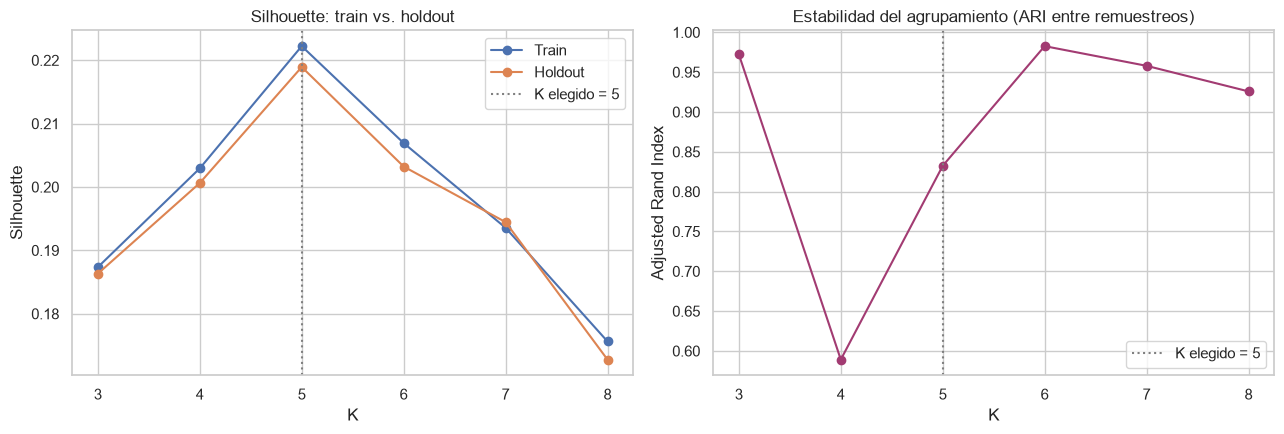

In [17]:
# ==============================================================================
# 10.1 GENERALIZACIÓN: SILHOUETTE EN TRAIN VS. HOLDOUT
# ==============================================================================
from sklearn.metrics import adjusted_rand_score

rng = np.random.default_rng(RANDOM_STATE)
n = X_scaled.shape[0]
idx_shuffled = rng.permutation(n)
corte = int(n * 0.7)
idx_train, idx_holdout = idx_shuffled[:corte], idx_shuffled[corte:]

resultados_k = []
for k in range(3, 9):
    modelo_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    modelo_k.fit(X_scaled[idx_train])

    labels_train = modelo_k.labels_
    labels_holdout = modelo_k.predict(X_scaled[idx_holdout])

    sil_train = silhouette_score(X_scaled[idx_train], labels_train,
                                  sample_size=min(5000, len(idx_train)), random_state=RANDOM_STATE)
    sil_holdout = silhouette_score(X_scaled[idx_holdout], labels_holdout,
                                    sample_size=min(5000, len(idx_holdout)), random_state=RANDOM_STATE)

    # Estabilidad: mismo K, dos submuestras aleatorias distintas del 80% de los datos
    sub_a = rng.choice(n, size=int(n * 0.8), replace=False)
    sub_b = rng.choice(n, size=int(n * 0.8), replace=False)
    modelo_a = KMeans(n_clusters=k, random_state=1, n_init=10).fit(X_scaled[sub_a])
    modelo_b = KMeans(n_clusters=k, random_state=2, n_init=10).fit(X_scaled[sub_b])
    ari = adjusted_rand_score(modelo_a.predict(X_scaled), modelo_b.predict(X_scaled))

    resultados_k.append({
        "K": k, "silhouette_train": sil_train, "silhouette_holdout": sil_holdout,
        "brecha": sil_train - sil_holdout, "estabilidad_ARI": ari,
    })

df_gen = pd.DataFrame(resultados_k)
display(df_gen.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(df_gen["K"], df_gen["silhouette_train"], marker="o", label="Train")
axes[0].plot(df_gen["K"], df_gen["silhouette_holdout"], marker="o", label="Holdout")
axes[0].axvline(K_FINAL, color="grey", linestyle=":", label=f"K elegido = {K_FINAL}")
axes[0].set(title="Silhouette: train vs. holdout", xlabel="K", ylabel="Silhouette")
axes[0].legend()

axes[1].plot(df_gen["K"], df_gen["estabilidad_ARI"], marker="o", color="#A23B72")
axes[1].axvline(K_FINAL, color="grey", linestyle=":", label=f"K elegido = {K_FINAL}")
axes[1].set(title="Estabilidad del agrupamiento (ARI entre remuestreos)", xlabel="K", ylabel="Adjusted Rand Index")
axes[1].legend()

plt.tight_layout()
plt.show()